In [1]:
from env import (
    MultiLeafThreadEnv,
    ThreadingConfig,
)
import torch
import random
from viz import draw_local_tree_sequence, draw_tree_edge_index
from utils import _timed_tree_to_graph_full
import matplotlib.pyplot as plt

In [2]:
REFERENCE_FULL_TREES = [
    {
        "sites": (0, 4),
        "tree": ("n", 2.0, ("n", 1.0, ("n", 1.0, 0, 1), 2), 3),
    },
    {
        "sites": (4, 8),
        "tree": ("n", 2.0, ("n", 0.25, 0, 2), ("n", 0.25, 1, 3)),
    },
]

GENO = torch.tensor(
    [
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
    ],
    dtype=torch.long,
)
LEAF_NAMES = ["A", "B", "C", "D"]
ALL_LEAF_IDS = [0, 1, 2, 3]
TIME_GRID = (0.25, 0.5, 1.0, 2.0, 4.0)


In [ ]:
multi_env_cfg = ThreadingConfig.from_raw(GENO, TIME_GRID, 0.4, 0.35, 0.15)
multi_env = MultiLeafThreadEnv(multi_env_cfg, ALL_LEAF_IDS, REFERENCE_FULL_TREES)

In [4]:
from viz import draw_tree_edge_index

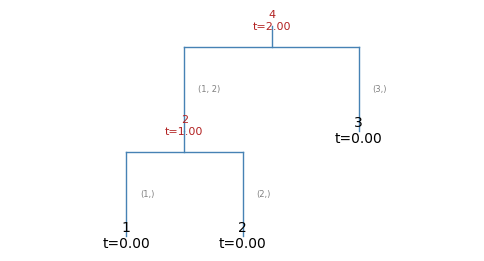

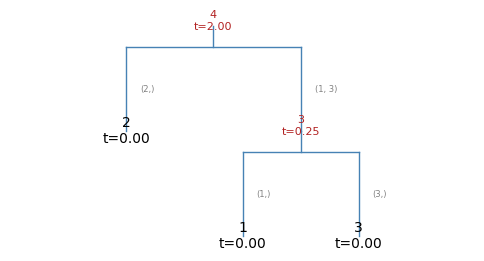

In [5]:
st = multi_env.reset()

for i in multi_env._inner_env.backbone_segments:
    draw_tree_edge_index(i)

In [ ]:
st = multi_env.reset()
valid_acts = multi_env.valid_actions(st)
print(len(valid_acts))
print(valid_acts)

In [ ]:
st = multi_env.reset()
valid_acts = multi_env.valid_actions(st)
for i in range(len(valid_acts)):
    k = multi_env.describe_action(st, valid_acts[i])
    print(k)

In [ ]:
len(valid_acts)

In [ ]:
len(multi_env._inner_env.site_choices)

(1,) 0.25


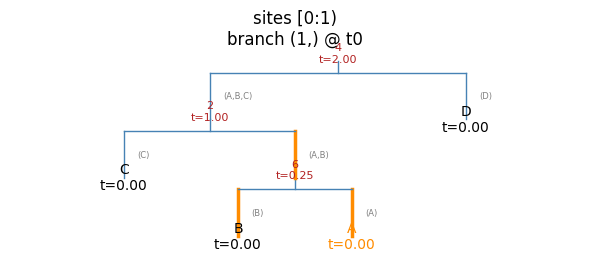

(1,) 0.5


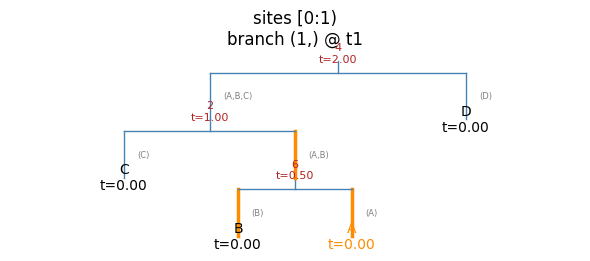

(1,) 1.0


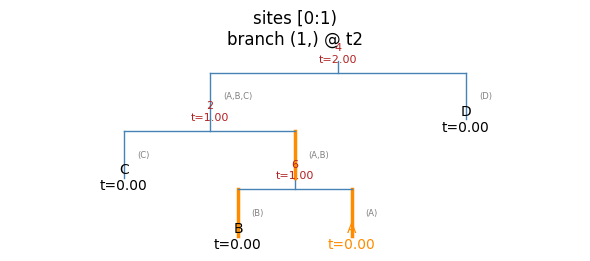

(2,) 0.25


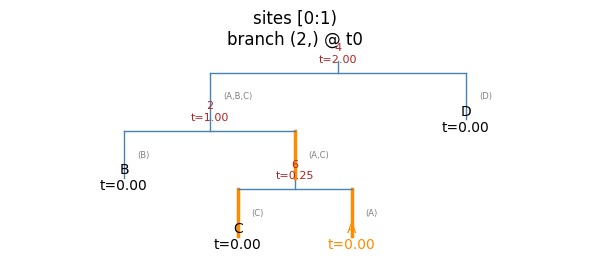

(2,) 0.5


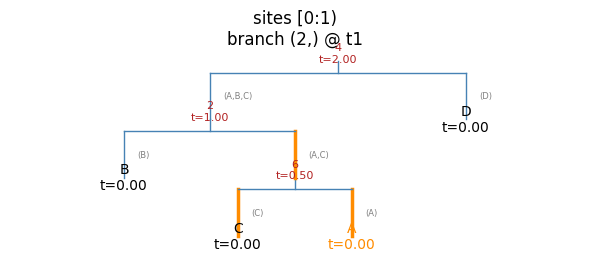

(1, 2) 2.0


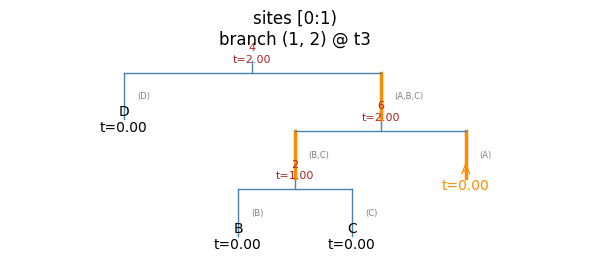

(3,) 0.25


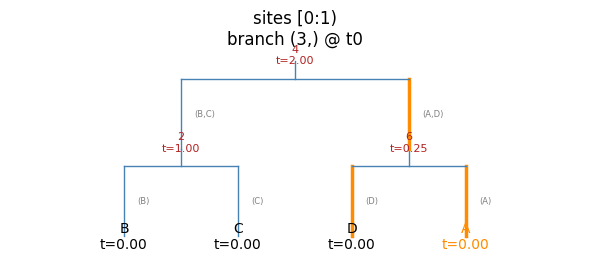

(3,) 0.5


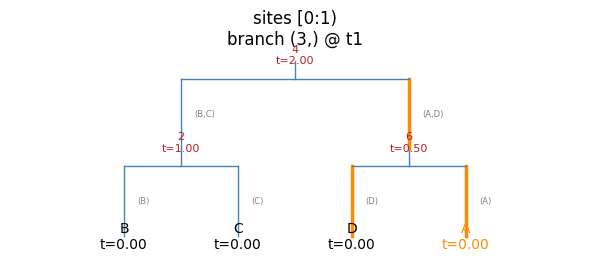

(3,) 1.0


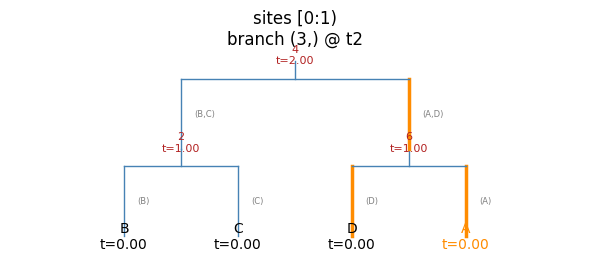

(1, 2, 3) 4.0


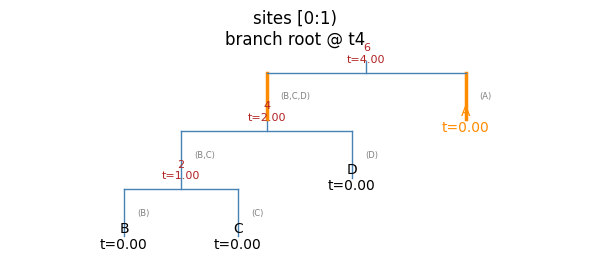

In [6]:
st = multi_env.reset()
valid_acts = multi_env.valid_actions(st)
for i in valid_acts:
    st = multi_env.reset()
    choice = multi_env._inner_env.site_choices[st.inner_state.site_index][valid_acts[i]]
    print(choice.branch_signature, choice.time_value)

    st, reward, done = multi_env.step(st, valid_acts[i])
    # Get the local trees with the focal leaf threaded in

    local_trees = multi_env._inner_env.snapshot_state(st.inner_state)

    # Visualize as a tree sequence
    draw_local_tree_sequence(local_trees, leaf_names=["A", "B", "C", "D"])

In [ ]:

# Convert the timed tree tuple format into graphs expected by the visualizer
rendered_trees = []
for item in st.current_full_trees:
    start, end = item["sites"]
    edge_index, num_nodes, root, node_times, node_sample_ids = _timed_tree_to_graph_full(item["tree"])
    
    rendered_trees.append({
        "edge_index": edge_index,
        "num_nodes": num_nodes,
        "root": root,
        "node_times": node_times,
        "node_sample_ids": node_sample_ids,
        "start": start,
        "end": end,
    })

# Draw the sequence, passing your leaf names if you have them defined!
draw_local_tree_sequence(rendered_trees, leaf_names=["A", "B", "C", "D"])
